In [1]:
import pandas as pd
from db import get_engine

def clv_analysis():
    engine = get_engine()

    query = """
        SELECT
            bh.[Mã_KH],
            bh.[Ngày_hạch_toán],
            bh.[Đơn_hàng],
            bh.[Số_lượng_bán],
            bh.[Doanh_thu],
            kh.[Loại_Khách_hàng]
        FROM dbo.dulieubanhang bh
        LEFT JOIN dbo.khachhang kh ON bh.[Mã_KH] = kh.[Mã_KH]
    """
    with engine.connect() as conn:
        df = pd.read_sql(query, conn)
    return df

df = clv_analysis()

df = df[df['Số_lượng_bán'] > 0]
df = df[df['Doanh_thu'] > 0] #Remove rows with zero or negative revenue, which may indicate returns or data errors
df = df[~df['Mã_KH'].isna()]
df.isna().sum() #To remove rows with missing customer id

Q = df[['Số_lượng_bán', 'Doanh_thu']].quantile(0.99)

# Filter out outliers in the Doanh_thu and Số_lượng_bán column
df = df[~(df['Số_lượng_bán'] > Q["Số_lượng_bán"])]
df = df[~(df['Doanh_thu'] > Q["Doanh_thu"])]

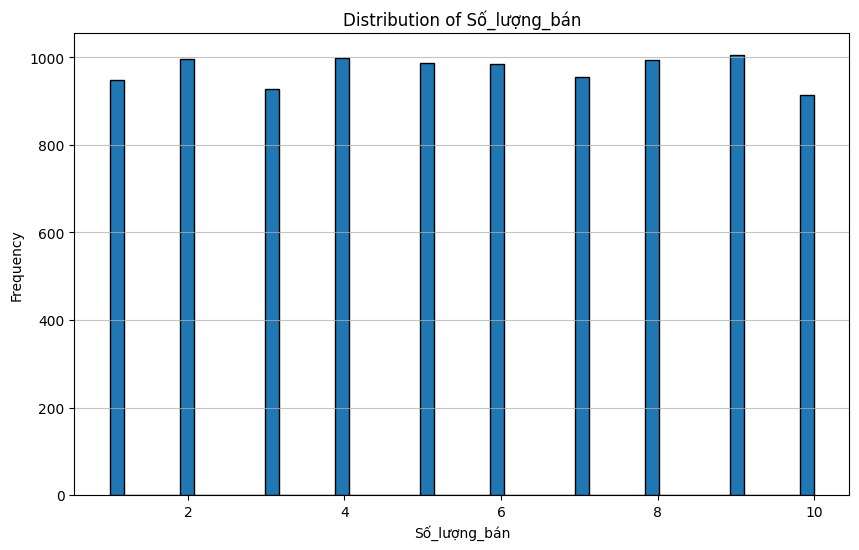

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Số_lượng_bán'], bins=50, edgecolor='k')
plt.title('Distribution of Số_lượng_bán')
plt.xlabel('Số_lượng_bán')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

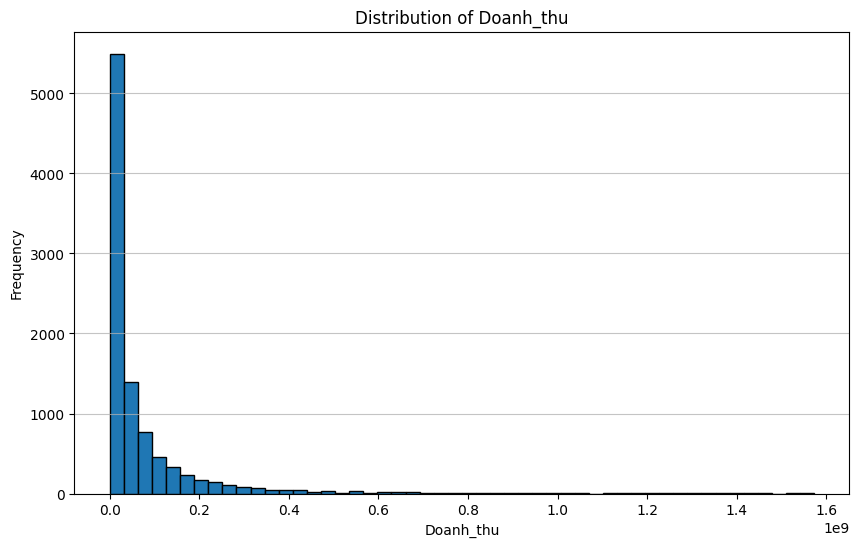

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(df['Doanh_thu'], bins=50, edgecolor='k')
plt.title('Distribution of Doanh_thu')
plt.xlabel('Doanh_thu')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [30]:
from dateutil.relativedelta import relativedelta
df['Ngày_hạch_toán'] = pd.to_datetime(df['Ngày_hạch_toán'])

df['First_Purchase'] = df.Mã_KH.map(df.groupby("Mã_KH").Ngày_hạch_toán.min().to_dict())

# Calculate the difference in months between the InvoiceDate column and the latest purchase date
def calculate_relative_difference(x):
    diff = relativedelta(x['Ngày_hạch_toán'], x["First_Purchase"])
    return diff.years * 12 + diff.months

df['MonthsSinceFirstPurchase'] = df.apply(calculate_relative_difference, axis=1)

# Group the data by customer and calculate their total spending, total purchases, and latest purchase date
df["Ngày_hạch_toán2"] = df["Ngày_hạch_toán"]
customer_data = df.groupby(['Mã_KH', 'MonthsSinceFirstPurchase']).agg({
    'Doanh_thu': 'sum',
    'Đơn_hàng': 'nunique',
    'Ngày_hạch_toán': 'min',
    'Ngày_hạch_toán2': 'max'
}).reset_index()

# Rename the columns
customer_data.columns = ['CustomerID', 'MonthsSinceFirstPurchase', 'TotalSpending', 'TotalPurchases', 'FirstPurchaseDate', 'LatestPurchaseDate']
customer_data.head()

,CustomerID,MonthsSinceFirstPurchase,TotalSpending,TotalPurchases,FirstPurchaseDate,LatestPurchaseDate
0,KH-0001,0,24255000.0,2,2024-01-09,2024-01-13
1,KH-0001,1,197370000.0,3,2024-02-17,2024-03-06
2,KH-0001,3,79575000.0,1,2024-04-12,2024-04-12
3,KH-0001,5,247950000.0,2,2024-06-25,2024-06-28
4,KH-0001,8,158895000.0,2,2024-09-17,2024-10-02


In [31]:
customer_data = customer_data[((customer_data.LatestPurchaseDate.max() - customer_data.FirstPurchaseDate).dt.days >= 183)]

customer_data = customer_data[['CustomerID', "MonthsSinceFirstPurchase", 'TotalSpending', 'TotalPurchases']]
X = pd.pivot(customer_data[customer_data["MonthsSinceFirstPurchase"] <= 2], index="CustomerID", columns=["MonthsSinceFirstPurchase"]).fillna(0)
# Flatten the MultiIndex columns of X
X.columns = ['_'.join(str(s) for s in col) for col in X.columns.values]
X.head()

,TotalSpending_0,TotalSpending_1,TotalSpending_2,TotalPurchases_0,TotalPurchases_1,TotalPurchases_2
CustomerID,,,,,,
KH-0001,2.425500e+07,197370000.0,0.0,2.0,3.0,0.0
KH-0002,1.155150e+08,1770000.0,10920000.0,2.0,1.0,1.0
KH-0003,2.439000e+07,4875000.0,0.0,2.0,1.0,0.0
KH-0004,1.460880e+09,45780000.0,93720000.0,3.0,1.0,2.0
KH-0005,1.308600e+08,76905000.0,2025000.0,2.0,1.0,1.0


In [32]:
#Predict the total spending in the first 6 months using the total spending in the first 3 months
cltv = customer_data[customer_data["MonthsSinceFirstPurchase"] <= 5].groupby("CustomerID").TotalSpending.sum().rename("cltv")
prepared_data = X.join(cltv)

# Split the data into features (X) and target variable (y)
X = prepared_data.drop("cltv", axis=1).values
y = prepared_data["cltv"].values
prepared_data.head()

,TotalSpending_0,TotalSpending_1,TotalSpending_2,TotalPurchases_0,TotalPurchases_1,TotalPurchases_2,cltv
CustomerID,,,,,,,
KH-0001,2.425500e+07,197370000.0,0.0,2.0,3.0,0.0,5.491500e+08
KH-0002,1.155150e+08,1770000.0,10920000.0,2.0,1.0,1.0,2.107800e+08
KH-0003,2.439000e+07,4875000.0,0.0,2.0,1.0,0.0,2.926500e+07
KH-0004,1.460880e+09,45780000.0,93720000.0,3.0,1.0,2.0,1.626240e+09
KH-0005,1.308600e+08,76905000.0,2025000.0,2.0,1.0,1.0,2.680650e+08


In [33]:
#Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Cross-validation

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
def run_kfold_cv(X, y, model):
    # Initialize the KFold class
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize a list to store the scores
    mse_scores = []
    mae_scores = []
    mape_scores = []

    # Loop through each fold
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)

        # Use the model to make predictions on the testing set
        y_pred = model.predict(X_test)

        # Calculate the mean squared error (MSE) and store it in the list
        mse_scores.append(mean_squared_error(y_test, y_pred))
        # Calculate the mean absolute error (MAE) and store it in the list
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        # Calculate the mean absolute percentage error (MAPE) and store it in the list
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))

    # Calculate the average score
    return  sum(mse_scores) / len(mse_scores), sum(mae_scores) / len(mae_scores), sum(mape_scores) / len(mape_scores)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

for model_name, model in [
    ("Linear regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor()),
    ("Gradient Boosting", GradientBoostingRegressor()),
]:
    scores = run_kfold_cv(X_train, y_train, model)
    print("{}: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(model_name, *scores))

Linear regression: MSE 77351615730865104.00, MAE 179328632.63, MAPE 1.13
Random Forest: MSE 95607998111815104.00, MAE 201168694.38, MAPE 1.21
Gradient Boosting: MSE 94688700775546384.00, MAE 196596931.30, MAPE 1.20


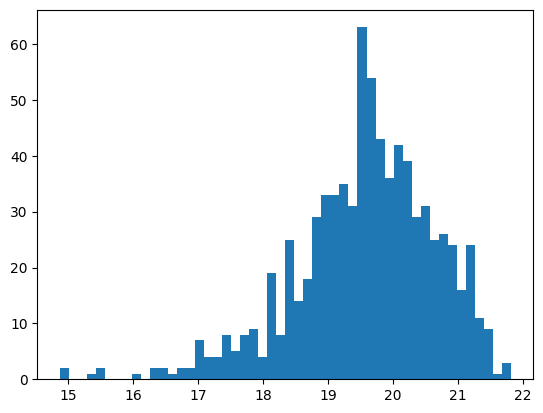

In [35]:
from matplotlib import pyplot as plt
import numpy as np
plt.hist(np.log(y), bins=50);

Use logarithm of y_train 

In [38]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error


def run_kfold_cv_log(X, y, model):
    # Initialize the KFold class
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize a list to store the scores
    mse_scores = []
    mae_scores = []
    mape_scores = []

    # Loop through each fold
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, np.log(y_train))

        # Use the model to make predictions on the testing set
        y_pred = np.exp(model.predict(X_test))

        # Calculate the mean squared error (MSE) and store it in the list
        mse_scores.append(mean_squared_error(y_test, y_pred))
        # Calculate the mean absolute error (MAE) and store it in the list
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        # Calculate the mean absolute percentage error (MAPE) and store it in the list
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))

    # Calculate the average score
    return  sum(mse_scores) / len(mse_scores), sum(mae_scores) / len(mae_scores), sum(mape_scores) / len(mape_scores)

for model_name, model in [
    ("Linear regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor()),
    ("Gradient Boosting", GradientBoostingRegressor()),
]:
    scores = run_kfold_cv_log(X_train, y_train, model)
    print("{}: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(model_name, *scores))

Linear regression: MSE 433597741050334272.00, MAE 253981547.25, MAPE 0.94
Random Forest: MSE 94844483904113664.00, MAE 180049729.94, MAPE 0.68
Gradient Boosting: MSE 95977454427605488.00, MAE 183204979.36, MAPE 0.69


In [40]:
X_transformed = np.concatenate([np.log1p(X_train[:, :3]), X_train[:, 3:]], axis=1)

for model_name, model in [
    ("Linear regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor()),
    ("Gradient Boosting", GradientBoostingRegressor()),
]:
    scores = run_kfold_cv_log(X_transformed, y_train, model)
    print("{}: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(model_name, *scores))

Linear regression: MSE 191375464667438176.00, MAE 273906387.91, MAPE 1.01
Random Forest: MSE 95166201017871840.00, MAE 180768996.71, MAPE 0.71
Gradient Boosting: MSE 95606393402349296.00, MAE 183058778.30, MAPE 0.70


Randomized Search

In [43]:
from sklearn.model_selection import RandomizedSearchCV

# Initialize a random forest regressor object
gbm = GradientBoostingRegressor()

# Define a dictionary of hyperparameters and their ranges
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize a grid search cross-validation object
random_search = RandomizedSearchCV(gbm, param_grid, cv=5, scoring='neg_mean_squared_error',  n_jobs=-1, random_state=42)

# Fit the grid search object to the data
random_search.fit(X_transformed, np.log(y_train))

# Print the best hyperparameters and their corresponding score
print('Best hyperparameters:', random_search.best_params_)
print('Best score:', -random_search.best_score_)

Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.05}
Best score: 0.5840608657938358


In [44]:
X_transformed_test = np.concatenate([np.log1p(X_test[:, :3]), X_test[:, 3:]], axis=1)
y_test_pred = np.exp(random_search.best_estimator_.predict(X_transformed_test))


print("GradientBoosting: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(
    mean_squared_error(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred),
    mean_absolute_percentage_error(y_test, y_test_pred)
))


GradientBoosting: MSE 178517765942794400.00, MAE 215602016.95, MAPE 0.50


In [45]:
def run_kfold_averaging(X, y, X_test, y_test, model):
    # Initialize the KFold class
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize a list to store the scores
    mse_scores = []
    mae_scores = []
    mape_scores = []
    preds = []
    # Loop through each fold
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train = X[train_index]
        y_train = y[train_index]

        model = GradientBoostingRegressor(**random_search.best_params_)
        model.fit(X_train, np.log(y_train))

        # Use the model to make predictions on the testing set
        y_pred = np.exp(model.predict(X_test))
        preds.append(y_pred)

        # Calculate the mean squared error (MSE) and store it in the list
        mse_scores.append(mean_squared_error(y_test, y_pred))
        # Calculate the mean absolute error (MAE) and store it in the list
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        # Calculate the mean absolute percentage error (MAPE) and store it in the list
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))
    preds = np.array(preds).mean(0)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return mse, mae, mape, np.mean(mse_scores), np.mean(mae_scores), np.mean(mape_scores)

In [ ]:
scores = run_kfold_averaging(X, y, X_test, y_test, GradientBoostingRegressor(**random_search.best_params_))

print("Average of individual models scores: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(*scores[3:]))
print("Average of different models predictions: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(*scores[:3]))

Average of individual models scores: MSE 137159390137826048.00, MAE 174383814.90, MAPE 0.41
Average of different models predictions: MSE 124804235357999232.00, MAE 166161337.09, MAPE 0.40


Grid Search

In [47]:
from sklearn.model_selection import GridSearchCV

# Initialize a random forest regressor object
gbm = GradientBoostingRegressor()

# Define a dictionary of hyperparameters and their ranges
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize a grid search cross-validation object
grid_search = GridSearchCV(gbm, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search object to the data
grid_search.fit(X_transformed, np.log(y_train))

# Print the best hyperparameters and their corresponding score
print('Best hyperparameters:', grid_search.best_params_)
print('Best score:', -grid_search.best_score_)


Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Best score: 0.5606412678227897


In [48]:
X_transformed_test = np.concatenate([np.log1p(X_test[:, :3]), X_test[:, 3:]], axis=1)
y_test_pred = np.exp(grid_search.predict(X_transformed_test))


print("GradientBoosting: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(
    mean_squared_error(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred),
    mean_absolute_percentage_error(y_test, y_test_pred)
))

GradientBoosting: MSE 174877388764975584.00, MAE 218343388.39, MAPE 0.51


In [49]:
def run_kfold_averaging(X, y, X_test, y_test, model):
    # Initialize the KFold class
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize a list to store the scores
    mse_scores = []
    mae_scores = []
    mape_scores = []
    preds = []
    # Loop through each fold
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train = X[train_index]
        y_train = y[train_index]

        model = GradientBoostingRegressor(**grid_search.best_params_)
        model.fit(X_train, np.log(y_train))

        # Use the model to make predictions on the testing set
        y_pred = np.exp(model.predict(X_test))
        preds.append(y_pred)

        # Calculate the mean squared error (MSE) and store it in the list
        mse_scores.append(mean_squared_error(y_test, y_pred))
        # Calculate the mean absolute error (MAE) and store it in the list
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        # Calculate the mean absolute percentage error (MAPE) and store it in the list
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))
    preds = np.array(preds).mean(0)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return mse, mae, mape, np.mean(mse_scores), np.mean(mae_scores), np.mean(mape_scores)

In [50]:
scores = run_kfold_averaging(X, y, X_test, y_test, GradientBoostingRegressor(**grid_search.best_params_))

print("Average of individual models scores: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(*scores[3:]))
print("Average of different models predictions: MSE {:.2f}, MAE {:.2f}, MAPE {:.2f}".format(*scores[:3]))

Average of individual models scores: MSE 159219536979893504.00, MAE 203034382.10, MAPE 0.49
Average of different models predictions: MSE 153040325283586816.00, MAE 201833651.32, MAPE 0.51
